# 📄 Resume Analyzer — ML Model Processing Pipeline

## Step 0: Initialization
- Import libraries for data handling
- Import machine learning models
- Import evaluation metrics
- Set up visualization tools

In [2]:
# ================================
# Step 0: Library Imports
# ================================

# Data Handling
import pandas as pd
import numpy as np

# Feature Extraction
from sklearn.feature_extraction.text import TfidfVectorizer

# Model Selection
from sklearn.model_selection import train_test_split

# Machine Learning Models
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Optional (for saving model later)
import joblib

print("Initialization complete")

Initialization complete


## Step 1: Data Loading and Problem Definition

### Objective
The objective of this step is to load the cleaned dataset and define the machine learning problem.

---

### Problem Definition

Given a resume (text), the goal is to predict its corresponding job category.

This is a:
- Supervised Learning problem
- Multi-class Classification problem

---

### Input and Output

- Input Feature (X): Final_Resume (cleaned text)
- Target Variable (y): Category

---

### Description

In this step, we:
- Load the cleaned dataset generated from the NLP pipeline
- Inspect the dataset structure
- Separate input features and target labels

This prepares the data for feature extraction and model training.

In [3]:
df = pd.read_csv("../data/resume_cleaned.csv")

print("Dataset Preview:\n")
display(df.head())


# ================================
# Dataset Information
# ================================

print("\nDataset Shape:")
print(df.shape)

print("\nColumns:")
print(df.columns.tolist())


# ================================
# Define Features and Labels
# ================================

X = df['Final_Resume']
y = df['Category']

print("\nSample Input Text:\n")
print(X.iloc[0][:300])

print("\nSample Label:")
print(y.iloc[0])

Dataset Preview:



,Final_Resume,Category
0,hr administrator marketing associate hr admini...,HR
1,hr specialist u hr operation summary versatile...,HR
2,hr director summary year experience recruiting...,HR
3,hr specialist summary dedicated driven dynamic...,HR
4,hr manager skill highlight hr skill hr departm...,HR



Dataset Shape:
(2484, 2)

Columns:
['Final_Resume', 'Category']

Sample Input Text:

hr administrator marketing associate hr administrator summary dedicated customer service manager year experience hospitality customer service management respected builder leader customer focused team strives instill shared enthusiastic commitment customer service highlight focused customer satisfact

Sample Label:
HR


## Step 2: Label Encoding

In this step, we:
- Encode each category into a unique integer
- Store the mapping between labels and encoded values

This mapping will be used later to convert model predictions back to their original category names.

In [12]:
from sklearn.preprocessing import LabelEncoder

# Initialize encoder
label_encoder = LabelEncoder()

# Fit and transform labels
y_encoded = label_encoder.fit_transform(y)

print("Encoded Labels Sample:\n")
print(y_encoded[:10])


# ================================
# Label Mapping
# ================================

label_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))

print("\nLabel Mapping:\n")
for key, value in label_mapping.items():
    print(f"{key} → {value}")

Encoded Labels Sample:

[19 19 19 19 19 19 19 19 19 19]

Label Mapping:

ACCOUNTANT → 0
ADVOCATE → 1
AGRICULTURE → 2
APPAREL → 3
ARTS → 4
AUTOMOBILE → 5
AVIATION → 6
BANKING → 7
BPO → 8
BUSINESS-DEVELOPMENT → 9
CHEF → 10
CONSTRUCTION → 11
CONSULTANT → 12
DESIGNER → 13
DIGITAL-MEDIA → 14
ENGINEERING → 15
FINANCE → 16
FITNESS → 17
HEALTHCARE → 18
HR → 19
INFORMATION-TECHNOLOGY → 20
PUBLIC-RELATIONS → 21
SALES → 22
TEACHER → 23


## Step 3: Train-Test Split

In this step, we:
- Split the dataset into training and testing subsets
- Use stratified sampling to maintain class distribution
- Separate input features and encoded labels

The training set is used to train the model, while the testing set is used to evaluate its performance.

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)
# ================================
# Fix: Remove NaN / Empty Text
# ================================

# Replace NaN with empty string
X_train = X_train.fillna('')
X_test = X_test.fillna('')

# Optional: remove completely empty rows
X_train = X_train.replace('', 'empty')
X_test = X_test.replace('', 'empty')
print("Training Set Shape:", X_train.shape)
print("Testing Set Shape:", X_test.shape)

Training Set Shape: (1987,)
Testing Set Shape: (497,)


## Step 4: TF-IDF Vectorization

### Objective
The objective of this step is to convert textual data into numerical form using TF-IDF so that machine learning models can process it.

---

### What is TF-IDF?

TF-IDF (Term Frequency – Inverse Document Frequency) is a technique used to represent text data as numerical vectors based on word importance.

---

### Description

In this step, we:
- Convert resume text into numerical feature vectors
- Learn vocabulary from training data
- Transform both training and testing data

---

### Important Principle

The vectorizer is:
- **fitted only on training data**
- **applied (transformed) on test data**

This prevents data leakage and ensures fair evaluation.

---

### Output

Each resume is converted into a high-dimensional sparse vector where:
- Each dimension represents a word
- Each value represents importance of that word in the resume

In [14]:
vectorizer = TfidfVectorizer(max_features=5000)

# Fit on training data
X_train_tfidf = vectorizer.fit_transform(X_train)

# Transform test data
X_test_tfidf = vectorizer.transform(X_test)

print("TF-IDF Training Shape:", X_train_tfidf.shape)
print("TF-IDF Testing Shape:", X_test_tfidf.shape)

TF-IDF Training Shape: (1987, 5000)
TF-IDF Testing Shape: (497, 5000)


## Step 5: Model Training

### Objective
The objective of this step is to train multiple machine learning models on the TF-IDF features and compare their learning behavior on resume classification.

---

### Description

In this step, we train different classification algorithms to learn the relationship between resume text and job categories.

---

### Models Used

1. Support Vector Machine (SVM)
2. K-Nearest Neighbors (KNN)
3. Decision Tree (CART - Gini Index)
4. Random Forest
5. Artificial Neural Network (ANN)

These models represent different learning approaches:

- SVM → boundary-based learning
- KNN → instance-based learning
- Decision Tree → rule-based learning
- Random Forest → ensemble-based learning
- ANN → layered nonlinear learning

In [15]:
# ================================
# Step 5: Model Training
# ================================

from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

# Initialize models
svm_model = SVC(kernel='linear')

knn_model = KNeighborsClassifier(n_neighbors=5)

dt_model = DecisionTreeClassifier(criterion='gini', random_state=42)

rf_model = RandomForestClassifier(
    n_estimators=200,
    criterion='gini',
    random_state=42,
    n_jobs=-1
)

ann_model = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation='relu',
    solver='adam',
    max_iter=300,
    random_state=42
)

# ================================
# Train Models
# ================================

svm_model.fit(X_train_tfidf, y_train)
print("SVM training complete")

knn_model.fit(X_train_tfidf, y_train)
print("KNN training complete")

dt_model.fit(X_train_tfidf, y_train)
print("Decision Tree training complete")

rf_model.fit(X_train_tfidf, y_train)
print("Random Forest training complete")

ann_model.fit(X_train_tfidf, y_train)
print("ANN training complete")

SVM training complete
KNN training complete
Decision Tree training complete
Random Forest training complete
ANN training complete


## Step 6: Model Evaluation

### Objective
The objective of this step is to evaluate the performance of all trained models using standard classification metrics.

---

### Description

In this step, we:
- Generate predictions on test data
- Compute evaluation metrics for each model
- Compare all models in a unified table
- Visualize confusion matrices

---

### Metrics Used

- Accuracy
- Precision (Weighted)
- Recall (Weighted)
- F1 Score (Weighted)
- Specificity

---

### Note

Weighted averaging is used to account for class imbalance in multi-class classification.

,Model,Accuracy,Precision,Recall,F1 Score,Specificity
3,Random Forest,0.6821,0.7151,0.6821,0.6610,0.9861
0,SVM,0.6419,0.6539,0.6419,0.6371,0.9844
4,ANN,0.6258,0.6315,0.6258,0.6220,0.9837
2,Decision Tree,0.5513,0.5780,0.5513,0.5577,0.9805
1,KNN,0.5553,0.5582,0.5553,0.5401,0.9806


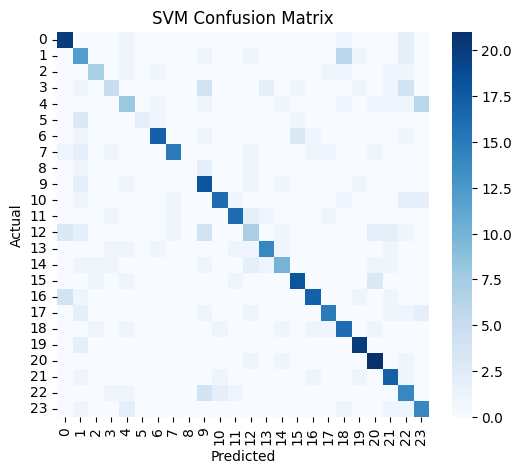

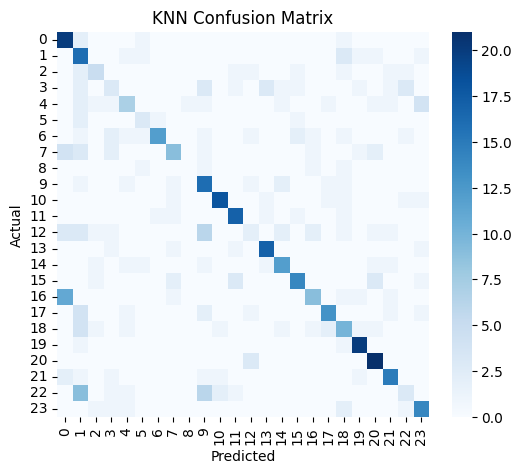

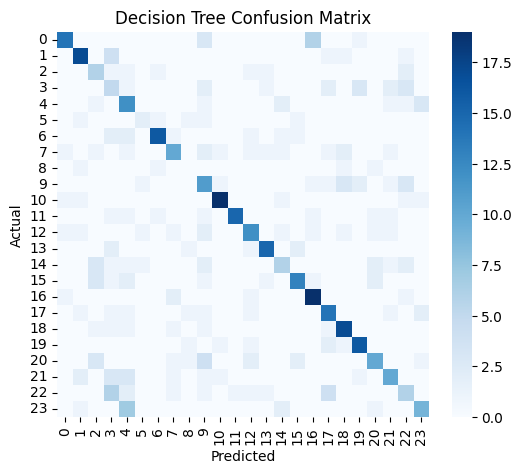

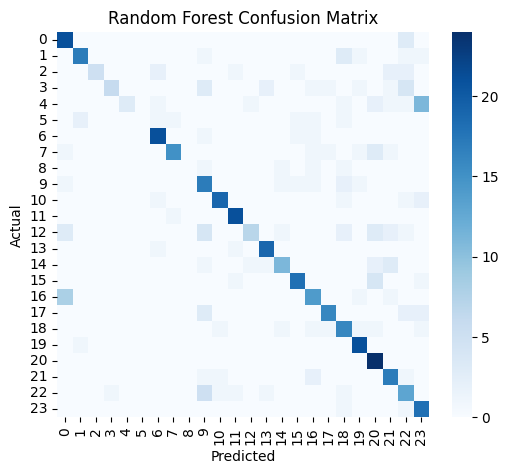

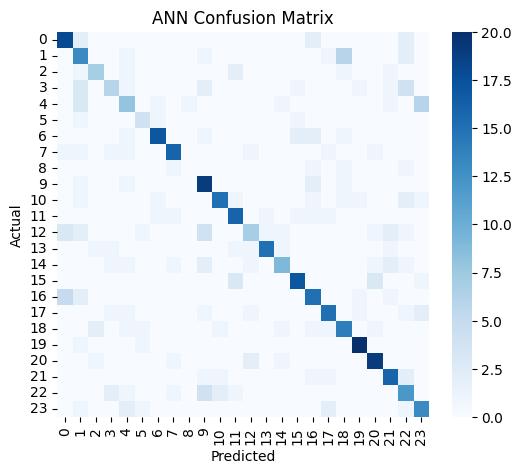

In [16]:
def calculate_specificity(conf_matrix):
    specificity_list = []
    
    for i in range(len(conf_matrix)):
        TP = conf_matrix[i, i]
        FN = sum(conf_matrix[i, :]) - TP
        FP = sum(conf_matrix[:, i]) - TP
        TN = conf_matrix.sum() - (TP + FN + FP)
        
        specificity = TN / (TN + FP) if (TN + FP) != 0 else 0
        specificity_list.append(specificity)
    
    return np.mean(specificity_list)


# Include Random Forest
models = {
    "SVM": svm_model,
    "KNN": knn_model,
    "Decision Tree": dt_model,
    "Random Forest": rf_model,
    "ANN": ann_model
}

results = []

# ================================
# Evaluation Loop
# ================================

for name, model in models.items():
    
    y_pred = model.predict(X_test_tfidf)
    
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    
    cm = confusion_matrix(y_test, y_pred)
    specificity = calculate_specificity(cm)
    
    results.append({
        "Model": name,
        "Accuracy": round(accuracy, 4),
        "Precision": round(precision, 4),
        "Recall": round(recall, 4),
        "F1 Score": round(f1, 4),
        "Specificity": round(specificity, 4)
    })


# ================================
# Results Table
# ================================

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="F1 Score", ascending=False)

display(results_df)


# ================================
# Confusion Matrix Visualization
# ================================

for name, model in models.items():
    
    y_pred = model.predict(X_test_tfidf)
    cm = confusion_matrix(y_test, y_pred)
    
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, cmap='Blues')
    
    plt.title(f"{name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    
    plt.show()

| Model         | Verdict       |
| ------------- | ------------- |
| Random Forest | ✅ BEST        |
| SVM           | ✅ Backup      |
| ANN           | ⚠️ Acceptable |
| Decision Tree | ❌ Reject      |
| KNN           | ❌ Reject      |


## Step 7: Overfitting and Underfitting Analysis

### Objective
The objective of this step is to analyze how well each model generalizes by comparing its performance on training and testing data.

---

### Concepts

- Overfitting:
  A model that performs extremely well on training data but poorly on testing data.

- Underfitting:
  A model that performs poorly on both training and testing data.

- Good Fit:
  A model where training and testing performance are reasonably high and close.

---

### Description

In this step, we:
- Compute accuracy on training data
- Compute accuracy on testing data
- Measure the gap between them
- Analyze model behavior

---

### Interpretation

- Large Gap → Overfitting  
- Small Gap + Low Accuracy → Underfitting  
- Small Gap + High Accuracy → Good Model  

In [17]:
# ================================
# Step 7: Overfitting Analysis
# ================================

train_results = []

for name, model in models.items():
    
    # Training Accuracy
    y_train_pred = model.predict(X_train_tfidf)
    train_acc = accuracy_score(y_train, y_train_pred)
    
    # Testing Accuracy
    y_test_pred = model.predict(X_test_tfidf)
    test_acc = accuracy_score(y_test, y_test_pred)
    
    train_results.append({
        "Model": name,
        "Train Accuracy": round(train_acc, 4),
        "Test Accuracy": round(test_acc, 4),
        "Gap": round(train_acc - test_acc, 4)
    })


# ================================
# Display Results
# ================================

overfit_df = pd.DataFrame(train_results)
overfit_df = overfit_df.sort_values(by="Gap", ascending=False)

display(overfit_df)

,Model,Train Accuracy,Test Accuracy,Gap
2,Decision Tree,1.0000,0.5513,0.4487
4,ANN,1.0000,0.6258,0.3742
3,Random Forest,1.0000,0.6821,0.3179
0,SVM,0.9190,0.6419,0.2771
1,KNN,0.6497,0.5553,0.0944


| Model         | Accuracy  | Gap       | Verdict    |
| ------------- | --------- | --------- | ---------- |
| Random Forest | ⭐ Highest | Moderate  | ✅ BEST     |
| SVM           | Good      | Lower     | ✅ Backup   |
| ANN           | Medium    | High      | ⚠️ Overfit |
| Decision Tree | Poor      | Very High | ❌ Reject   |
| KNN           | Poor      | Low       | ❌ Underfit |


## Step 8: Model Selection and Saving

### Objective
To select the best-performing model based on evaluation and save it for deployment.

---

### Selected Model

Random Forest is selected due to:
- Highest test accuracy
- Better handling of overfitting compared to Decision Tree
- Strong performance on TF-IDF features

In [ ]:
# ================================
# Step 8: Select Best Model
# ================================

best_model = rf_model

print("Selected Model: Random Forest")


# ================================
# Create Output Directory
# ================================

import os

output_dir = "../output"

if not os.path.exists(output_dir):
    os.makedirs(output_dir)


# ================================
# Save Model Artifacts
# ================================

import joblib

joblib.dump(best_model, os.path.join(output_dir, "model.pkl"))
joblib.dump(vectorizer, os.path.join(output_dir, "vectorizer.pkl"))
joblib.dump(label_encoder, os.path.join(output_dir, "encoder.pkl"))

print("\nFiles saved successfully:")
print("../output/model.pkl")
print("../output/vectorizer.pkl")
print("../output/encoder.pkl")

Selected Model: Random Forest

Files saved successfully:
output/model.pkl
output/vectorizer.pkl
output/encoder.pkl


| Concept        | Real World             |
| -------------- | ---------------------- |
| model.pkl      | trained brain          |
| vectorizer.pkl | language understanding |
| encoder.pkl    | dictionary             |
